In [1]:
import torch
import os
import pandas as pd
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

# Einstellungen
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIDENCE_THRESHOLD = 0.65

# Modell(e)
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

# Hauptdaten laden
df_base = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df_base = df_base.iloc[:2000].copy()
statements = df_base["statement"].tolist()

# Ergebnisse
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Prompt-Templates
def base_prompt(statement):
    return (
        f"Statement: {statement}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable facts.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

def tone_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking.\n"
        f"Statement: {statement}\n"
        f"Tone: {tone}\n"
        f"Task: Is the statement factually correct?\n"
        f"Respond with only one word: True or False.\n"
        f"Answer:"
    )

def subject_prompt(statement, subject):
    return (
        f"Statement: {statement}\n"
        f"Subjects: {subject}\n"
        f"Task: Is the statement factually correct considering these subjects?\n"
        f"Answer only with True or False.\n"
        f"Answer:"
    )

# Zusätzliche Daten vorbereiten (werden nur bei Bedarf geladen)
tone_data = None
subject_data = None

# Verarbeitung
for model_name, model_type in models.items():
    print(f"\n🚀 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token-IDs für " True" und " False"
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    for i in tqdm(range(len(statements)), desc="🔍 Bewertung"):
        statement = statements[i]

        def evaluate(prompt):
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                logits = model(**inputs).logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)
                return probs

        # Stufe 1
        prompt = base_prompt(statement)
        probs = evaluate(prompt)
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if max(prob_true, prob_false) >= CONFIDENCE_THRESHOLD:
            result = "True" if prob_true > prob_false else "False"
            confidence = max(prob_true, prob_false)
        else:
            # Stufe 2 – Tone nachladen
            if tone_data is None:
                print("📄 Lade Tone-Daten...")
                tone_data = pd.read_csv("statements_tone_cleaned.csv").iloc[:2000]
            tone = tone_data.iloc[i]["tone"]

            prompt = tone_prompt(statement, tone)
            probs = evaluate(prompt)
            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if max(prob_true, prob_false) >= CONFIDENCE_THRESHOLD:
                result = "True" if prob_true > prob_false else "False"
                confidence = max(prob_true, prob_false)
            else:
                # Stufe 3 – Subject nachladen
                if subject_data is None:
                    print("📄 Lade Subject-Daten...")
                    subject_data = pd.read_csv("preprocessed_test_with_domain.csv").iloc[:2000]
                subject = subject_data.iloc[i]["subjects"]

                prompt = subject_prompt(statement, subject)
                probs = evaluate(prompt)
                prob_true = probs[true_token_id].item()
                prob_false = probs[false_token_id].item()

                result = "True" if prob_true > prob_false else "False"
                confidence = max(prob_true, prob_false)

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df_base[f"label_{suffix}"] = results[model_name]
    df_base[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe
print("\n✅ Fertig. Beispiel:")
print(df_base[[f"statement", f"label_{suffix}", f"confidence_{suffix}"]].head())

# Optional: Speichern
# df_base.to_csv("final_results_reprompted.csv", index=False)



🚀 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


2025-07-03 07:37:11.005399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751521031.026390   26668 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751521031.031196   26668 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 07:37:11.049961: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Bewertung:   0%|          | 0/1267 [00:00<?, ?it/s]

📄 Lade Tone-Daten...
📄 Lade Subject-Daten...


🔍 Bewertung: 100%|██████████| 1267/1267 [04:39<00:00,  4.53it/s]


✅ Fertig. Beispiel:
                                           statement  \
0  Building a wall on the U.S . Mexico border wil...   
1  Wisconsin is on pace to double the number of l...   
2  Says John McCain has done nothing to help the ...   
3  Suzanne Bonamici supports a plan that will cut...   
4  When asked by a reporter whether hes at the ce...   

  label_Llama-3.1-8B-Instruct  confidence_Llama-3.1-8B-Instruct  
0                       False                          0.384658  
1                       False                          0.727298  
2                       False                          0.811939  
3                       False                          0.725634  
4                       False                          0.741350  


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
df=df_base
# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[ 98 616]
 [ 34 519]]

Accuracy:  0.48697711128650356
Precision: 0.7424242424242424  (bezogen auf 'True')
Recall:    0.13725490196078433  (bezogen auf 'True')
F1 Score:  0.23167848699763594  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.46      0.94      0.61       553
       False       0.74      0.14      0.23       714

    accuracy                           0.49      1267
   macro avg       0.60      0.54      0.42      1267
weighted avg       0.62      0.49      0.40      1267



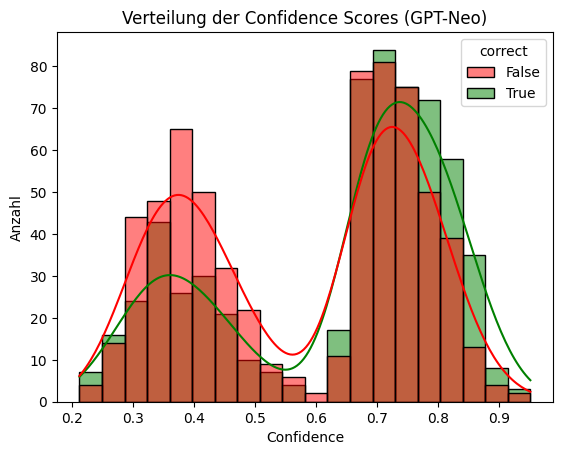

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# self consistency

In [1]:
import torch
import os
import pandas as pd
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import random
from collections import Counter

# Einstellungen
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modell(e)
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

# Hauptdaten laden
df_base = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df_base = df_base.iloc[:2000].copy()
statements = df_base["statement"].tolist()

# Ergebnisse
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Self-consistency: leichte Variationen von Prompts
def self_consistency_prompt_variants(statement, n=5):
    variants = [
        f"Statement: {statement}\nTask: Is this factually correct? Answer:",
        f"Please determine if the following is true or false:\n'{statement}'\nAnswer:",
        f"Fact-check the statement: {statement}\nReply with only True or False.\nAnswer:",
        f"Analyze this statement for factual accuracy:\n{statement}\nAnswer (True/False):",
        f"True or False?\nStatement: {statement}\nAnswer:",
        f"Is this statement true?\n{statement}\nAnswer:",
        f"Does the following statement reflect a factual truth?\n{statement}\nAnswer:"
    ]
    return random.sample(variants, k=min(n, len(variants)))

# Self-consistency Bewertung mit Mehrheitsentscheid
def evaluate_self_consistency(statement, tokenizer, model, true_token_id, false_token_id, n=5, use_weighted=False):
    prompts = self_consistency_prompt_variants(statement, n)
    answers = []
    weights = {"True": 0.0, "False": 0.0}

    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            next_token_logits = logits[0, -1, :]
            probs = F.softmax(next_token_logits, dim=-1)
            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            answers.append("True")
            weights["True"] += prob_true if use_weighted else 1.0
        else:
            answers.append("False")
            weights["False"] += prob_false if use_weighted else 1.0

    final_answer = "True" if weights["True"] > weights["False"] else "False"
    confidence = weights[final_answer] / sum(weights.values())
    return final_answer, confidence

# Verarbeitung
for model_name, model_type in models.items():
    print(f"\n🚀 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    for i in tqdm(range(len(statements)), desc="🔍 Bewertung"):
        statement = statements[i]
        result, confidence = evaluate_self_consistency(
            statement,
            tokenizer,
            model,
            true_token_id,
            false_token_id,
            n=5,              # Anzahl Re-Prompts
            use_weighted=True # True = Wahrscheinlichkeiten gewichten
        )

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df_base[f"label_{suffix}"] = results[model_name]
    df_base[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe
print("\n✅ Fertig. Beispiel:")
print(df_base[[f"statement", f"label_{suffix}", f"confidence_{suffix}"]].head())

# Optional speichern
# df_base.to_csv("final_results_self_consistency.csv", index=False)



🚀 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


2025-07-03 07:28:22.560933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751520502.579245   26262 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751520502.584032   26262 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 07:28:22.603273: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Bewertung: 100%|██████████| 1267/1267 [07:00<00:00,  3.01it/s]


✅ Fertig. Beispiel:
                                           statement  \
0  Building a wall on the U.S . Mexico border wil...   
1  Wisconsin is on pace to double the number of l...   
2  Says John McCain has done nothing to help the ...   
3  Suzanne Bonamici supports a plan that will cut...   
4  When asked by a reporter whether hes at the ce...   

  label_Llama-3.1-8B-Instruct  confidence_Llama-3.1-8B-Instruct  
0                        True                          0.501881  
1                        True                          0.512030  
2                       False                          0.914980  
3                       False                          1.000000  
4                       False                          0.861483  


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
df=df_base
# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[271 443]
 [139 414]]

Accuracy:  0.5406471981057617
Precision: 0.6609756097560976  (bezogen auf 'True')
Recall:    0.3795518207282913  (bezogen auf 'True')
F1 Score:  0.4822064056939502  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.75      0.59       553
       False       0.66      0.38      0.48       714

    accuracy                           0.54      1267
   macro avg       0.57      0.56      0.53      1267
weighted avg       0.58      0.54      0.53      1267



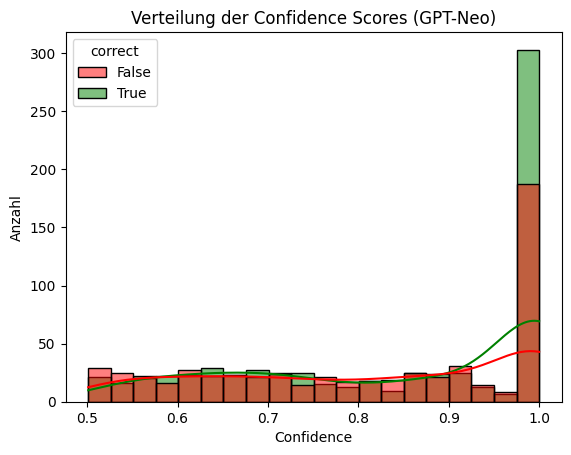

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

In [1]:
import torch
import os
import pandas as pd
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import random
from collections import Counter

# Einstellungen
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIDENCE_THRESHOLD = 0.75
N_VARIANTS = 5
USE_WEIGHTED = True

models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

df_base = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df_base = df_base.iloc[:2000].copy()
statements = df_base["statement"].tolist()

results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Deine Prompts
def base_prompt(statement):
    return (
        f"Statement: {statement}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable facts.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

def tone_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking.\n"
        f"Statement: {statement}\n"
        f"Tone: {tone}\n"
        f"Task: Is the statement factually correct?\n"
        f"Respond with only one word: True or False.\n"
        f"Answer:"
    )

def subject_prompt(statement, subject):
    return (
        f"Statement: {statement}\n"
        f"Subjects: {subject}\n"
        f"Task: Is the statement factually correct considering these subjects?\n"
        f"Answer only with True or False.\n"
        f"Answer:"
    )

# Variationen für Self-Consistency pro Prompt-Funktion
def generate_variants(prompt_func, statement, context=None, n=5):
    variants = []
    for _ in range(n):
        if context:
            variants.append(prompt_func(statement, context))
        else:
            variants.append(prompt_func(statement))
    return variants

# Self-consistency Voting
def evaluate_prompts(prompts, tokenizer, model, true_token_id, false_token_id, use_weighted=True):
    votes = {"True": 0.0, "False": 0.0}
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            next_token_logits = logits[0, -1, :]
            probs = F.softmax(next_token_logits, dim=-1)
            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            votes["True"] += prob_true if use_weighted else 1.0
        else:
            votes["False"] += prob_false if use_weighted else 1.0

    final = "True" if votes["True"] > votes["False"] else "False"
    confidence = votes[final] / (votes["True"] + votes["False"])
    return final, confidence

# Optionale Daten
tone_data = None
subject_data = None

# Haupt-Loop
for model_name, model_type in models.items():
    print(f"\n🚀 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    for i in tqdm(range(len(statements)), desc="🔍 Bewertung"):
        statement = statements[i]

        # STUFE 1: BASE
        base_variants = generate_variants(base_prompt, statement, n=N_VARIANTS)
        result, confidence = evaluate_prompts(base_variants, tokenizer, model, true_token_id, false_token_id, use_weighted=USE_WEIGHTED)

        if confidence < CONFIDENCE_THRESHOLD:
            # STUFE 2: TONE
            if tone_data is None:
                print("📄 Lade Tone-Daten...")
                tone_data = pd.read_csv("statements_tone_cleaned.csv").iloc[:2000]
            tone = tone_data.iloc[i]["tone"]
            tone_variants = generate_variants(tone_prompt, statement, tone, n=N_VARIANTS)
            result, confidence = evaluate_prompts(tone_variants, tokenizer, model, true_token_id, false_token_id, use_weighted=USE_WEIGHTED)

            if confidence < CONFIDENCE_THRESHOLD:
                # STUFE 3: SUBJECT
                if subject_data is None:
                    print("📄 Lade Subject-Daten...")
                    subject_data = pd.read_csv("preprocessed_test_with_domain.csv").iloc[:2000]
                subject = subject_data.iloc[i]["subjects"]
                subject_variants = generate_variants(subject_prompt, statement, subject, n=N_VARIANTS)
                result, confidence = evaluate_prompts(subject_variants, tokenizer, model, true_token_id, false_token_id, use_weighted=USE_WEIGHTED)

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnis speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df_base[f"label_{suffix}"] = results[model_name]
    df_base[f"confidence_{suffix}"] = confidences[model_name]

print("\n✅ Fertig. Beispiel:")
print(df_base[[f"statement", f"label_{suffix}", f"confidence_{suffix}"]].head())

# Optional speichern
# df_base.to_csv("final_results_self_consistency_reprompt.csv", index=False)



🚀 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


2025-07-03 07:42:36.352401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751521356.370796   27016 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751521356.375556   27016 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 07:42:36.394039: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Bewertung: 100%|██████████| 1267/1267 [09:51<00:00,  2.14it/s]


✅ Fertig. Beispiel:
                                           statement  \
0  Building a wall on the U.S . Mexico border wil...   
1  Wisconsin is on pace to double the number of l...   
2  Says John McCain has done nothing to help the ...   
3  Suzanne Bonamici supports a plan that will cut...   
4  When asked by a reporter whether hes at the ce...   

  label_Llama-3.1-8B-Instruct  confidence_Llama-3.1-8B-Instruct  
0                        True                               1.0  
1                        True                               1.0  
2                       False                               1.0  
3                       False                               1.0  
4                        True                               1.0  


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
df=df_base
# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[482 232]
 [249 304]]

Accuracy:  0.6203630623520127
Precision: 0.6593707250341997  (bezogen auf 'True')
Recall:    0.6750700280112045  (bezogen auf 'True')
F1 Score:  0.6671280276816609  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.57      0.55      0.56       553
       False       0.66      0.68      0.67       714

    accuracy                           0.62      1267
   macro avg       0.61      0.61      0.61      1267
weighted avg       0.62      0.62      0.62      1267



/tmp/ipykernel_27016/1377880084.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Vorhersage korrekt?")


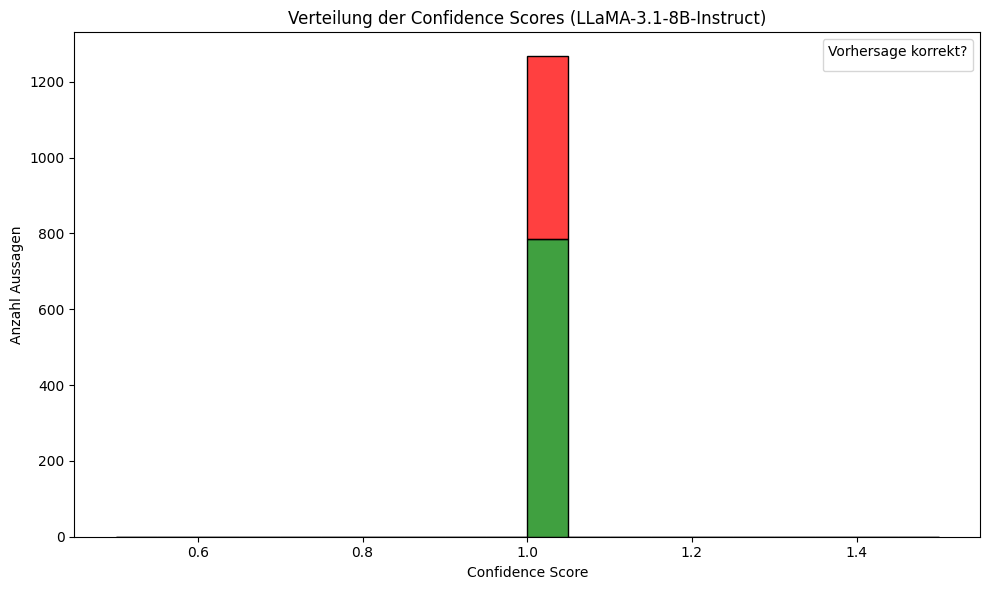

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Sicherstellen, dass Vergleich auf boolescher Ebene erfolgt
df["label_true"] = df["label"].apply(map_label)  # Ground truth: True/False
df["predicted"] = df["label_Llama-3.1-8B-Instruct"].apply(map_label)

# Korrekt oder nicht
df["correct"] = df["label_true"] == df["predicted"]

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="confidence_Llama-3.1-8B-Instruct",
    hue="correct",
    bins=20,
    kde=False,
    palette={True: "green", False: "red"},
    multiple="stack"  # besser für Überblick
)

plt.title("Verteilung der Confidence Scores (LLaMA-3.1-8B-Instruct)")
plt.xlabel("Confidence Score")
plt.ylabel("Anzahl Aussagen")
plt.legend(title="Vorhersage korrekt?")
plt.tight_layout()
plt.show()


# iterative self refinement

In [1]:
import torch
import os
import pandas as pd
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

# Einstellungen
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_REFINEMENT_STEPS = 3
CONFIDENCE_THRESHOLD = 0.75

models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

df_base = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df_base = df_base.iloc[:2000].copy()
statements = df_base["statement"].tolist()

results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Prompt Templates
def initial_prompt(statement):
    return (
        f"Statement: {statement}\n"
        f"Task: Is this statement factually correct or not?\n"
        f"Answer only with True or False and explain briefly why.\n"
        f"Answer:"
    )

def refinement_prompt(statement, previous_answer):
    return (
        f"You previously answered this:\n"
        f"Statement: {statement}\n"
        f"Your answer: {previous_answer}\n"
        f"Now reflect critically: Is your answer still correct? If not, revise it.\n"
        f"Respond again with True or False and a brief explanation.\n"
        f"Refined Answer:"
    )

# Antwort-Extraktion (True/False + Confidence)
def extract_answer_and_confidence(output_text, true_token_id, false_token_id, tokenizer, model, prompt):
    # Sicherstellen, dass wir am richtigen Token bewerten
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        next_token_logits = logits[0, -1, :]
        probs = F.softmax(next_token_logits, dim=-1)
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

    predicted = "True" if prob_true > prob_false else "False"
    confidence = max(prob_true, prob_false)
    return predicted, confidence

# Hauptloop
for model_name, model_type in models.items():
    print(f"\n🚀 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    for i in tqdm(range(len(statements)), desc="🔁 Self-Refinement"):
        statement = statements[i]
        step = 0
        previous_prompt = initial_prompt(statement)

        while step < MAX_REFINEMENT_STEPS:
            inputs = tokenizer(previous_prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
            output_text = tokenizer.decode(output[0], skip_special_tokens=True)
            full_response = output_text[len(previous_prompt):].strip()

            answer, confidence = extract_answer_and_confidence(full_response, true_token_id, false_token_id, tokenizer, model, previous_prompt)

            # Stop if confident enough
            if confidence >= CONFIDENCE_THRESHOLD:
                break

            # Else: refine
            previous_prompt = refinement_prompt(statement, full_response)
            step += 1

        results[model_name].append(answer)
        confidences[model_name].append(confidence)

# Speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df_base[f"label_{suffix}"] = results[model_name]
    df_base[f"confidence_{suffix}"] = confidences[model_name]

print("\n✅ Fertig. Beispiel:")
print(df_base[[f"statement", f"label_{suffix}", f"confidence_{suffix}"]].head())

# Optional: df_base.to_csv("final_results_self_refinement.csv", index=False)



🚀 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


2025-07-03 07:55:38.359224: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751522138.377453   27568 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751522138.382220   27568 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 07:55:38.401026: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔁 Self-Refinement: 100%|██████████| 1267/1267 [1:44:51<00:00,  4.97s/it]


✅ Fertig. Beispiel:
                                           statement  \
0  Building a wall on the U.S . Mexico border wil...   
1  Wisconsin is on pace to double the number of l...   
2  Says John McCain has done nothing to help the ...   
3  Suzanne Bonamici supports a plan that will cut...   
4  When asked by a reporter whether hes at the ce...   

  label_Llama-3.1-8B-Instruct  confidence_Llama-3.1-8B-Instruct  
0                       False                          0.678373  
1                       False                          0.539926  
2                       False                          0.003545  
3                       False                          0.576894  
4                       False                          0.027074  


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
df=df_base
# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[ 43 671]
 [ 33 520]]

Accuracy:  0.44435674822415155
Precision: 0.5657894736842105  (bezogen auf 'True')
Recall:    0.06022408963585434  (bezogen auf 'True')
F1 Score:  0.10886075949367088  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.44      0.94      0.60       553
       False       0.57      0.06      0.11       714

    accuracy                           0.44      1267
   macro avg       0.50      0.50      0.35      1267
weighted avg       0.51      0.44      0.32      1267



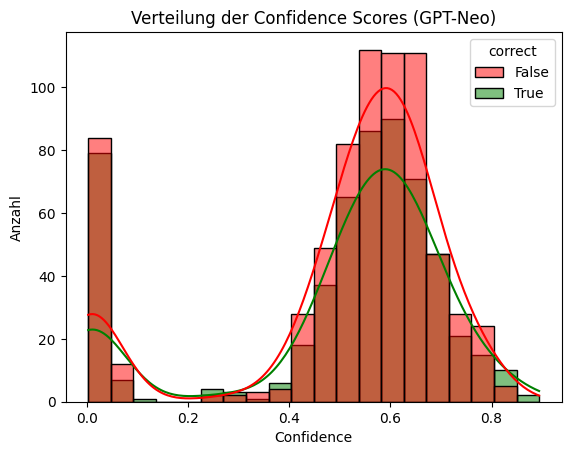

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

In [1]:
import torch
import os
import pandas as pd
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

# ⚙️ Einstellungen
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIDENCE_THRESHOLD = 0.75
MAX_REFINEMENT_STEPS = 2

models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

# 📄 Daten laden
df_base = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t")
df_base = df_base.iloc[:2000].copy()
statements = df_base["statement"].tolist()

results = {name: [] for name in models}
confidences = {name: [] for name in models}

# 🧾 Prompt-Templates (wie in deinem Original)
def base_prompt(statement):
    return (
        f"Statement: {statement}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable facts.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

def tone_prompt(statement, tone):
    return (
        f"You are an AI assistant specialized in fact-checking.\n"
        f"Statement: {statement}\n"
        f"Tone: {tone}\n"
        f"Task: Is the statement factually correct?\n"
        f"Respond with only one word: True or False.\n"
        f"Answer:"
    )

def subject_prompt(statement, subject):
    return (
        f"Statement: {statement}\n"
        f"Subjects: {subject}\n"
        f"Task: Is the statement factually correct considering these subjects?\n"
        f"Answer only with True or False.\n"
        f"Answer:"
    )

def refinement_prompt(statement, previous_output):
    return (
        f"Statement: {statement}\n"
        f"Earlier answer: {previous_output.strip()}\n"
        f"Please reflect critically. Is this answer still correct?\n"
        f"If necessary, revise it. Reply again with one word: True or False.\n"
        f"Refined answer:"
    )

# 🔎 Antwort & Confidence aus Prompt generieren
def get_prediction(prompt, tokenizer, model, true_token_id, false_token_id):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=50, pad_token_id=tokenizer.eos_token_id)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    completion = decoded[len(prompt):].strip()

    # Confidence berechnen (Token-Logits)
    with torch.no_grad():
        logits = model(**inputs).logits
        next_token_logits = logits[0, -1, :]
        probs = F.softmax(next_token_logits, dim=-1)
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

    predicted_label = "True" if prob_true > prob_false else "False"
    confidence = max(prob_true, prob_false)
    return predicted_label, confidence, completion

# Optionaldaten vorbereiten
tone_data = None
subject_data = None

# 🧠 Iterativer Entscheidungsprozess
def refine_prediction(statement, prompt_func, tokenizer, model, true_token_id, false_token_id, context=None):
    # Starte mit initialem Prompt
    if context:
        prompt = prompt_func(statement, context)
    else:
        prompt = prompt_func(statement)

    label, confidence, completion = get_prediction(prompt, tokenizer, model, true_token_id, false_token_id)

    step = 0
    while confidence < CONFIDENCE_THRESHOLD and step < MAX_REFINEMENT_STEPS:
        refinement = refinement_prompt(statement, completion)
        label, confidence, completion = get_prediction(refinement, tokenizer, model, true_token_id, false_token_id)
        step += 1

    return label, confidence

# 🔁 Hauptloop
for model_name, model_type in models.items():
    print(f"\n🚀 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    for i in tqdm(range(len(statements)), desc="🤖 Evaluierung mit Refinement"):
        statement = statements[i]

        # 🧪 Stufe 1: Base
        label, confidence = refine_prediction(statement, base_prompt, tokenizer, model, true_token_id, false_token_id)

        if confidence < CONFIDENCE_THRESHOLD:
            # 🧪 Stufe 2: Tone
            if tone_data is None:
                print("📄 Lade Tone-Daten...")
                tone_data = pd.read_csv("statements_tone_cleaned.csv").iloc[:2000]
            tone = tone_data.iloc[i]["tone"]
            label, confidence = refine_prediction(statement, tone_prompt, tokenizer, model, true_token_id, false_token_id, context=tone)

            if confidence < CONFIDENCE_THRESHOLD:
                # 🧪 Stufe 3: Subject
                if subject_data is None:
                    print("📄 Lade Subject-Daten...")
                    subject_data = pd.read_csv("preprocessed_test_with_domain.csv").iloc[:2000]
                subject = subject_data.iloc[i]["subjects"]
                label, confidence = refine_prediction(statement, subject_prompt, tokenizer, model, true_token_id, false_token_id, context=subject)

        results[model_name].append(label)
        confidences[model_name].append(confidence)

# Ergebnisse speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df_base[f"label_{suffix}"] = results[model_name]
    df_base[f"confidence_{suffix}"] = confidences[model_name]

print("\n✅ Fertig. Beispiel:")
print(df_base[[f"statement", f"label_{suffix}", f"confidence_{suffix}"]].head())

# Optional speichern
# df_base.to_csv("final_results_with_self_refinement.csv", index=False)



🚀 Lade Modell: meta-llama/Llama-3.1-8B-Instruct (causal)


2025-07-03 09:41:42.812735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751528502.831250   29190 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751528502.836283   29190 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 09:41:42.855256: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🤖 Evaluierung mit Refinement:   0%|          | 0/1267 [00:00<?, ?it/s]

📄 Lade Tone-Daten...
📄 Lade Subject-Daten...


🤖 Evaluierung mit Refinement: 100%|██████████| 1267/1267 [3:45:02<00:00, 10.66s/it]  


✅ Fertig. Beispiel:
                                           statement  \
0  Building a wall on the U.S . Mexico border wil...   
1  Wisconsin is on pace to double the number of l...   
2  Says John McCain has done nothing to help the ...   
3  Suzanne Bonamici supports a plan that will cut...   
4  When asked by a reporter whether hes at the ce...   

  label_Llama-3.1-8B-Instruct  confidence_Llama-3.1-8B-Instruct  
0                       False                          0.554335  
1                       False                          0.751271  
2                       False                          0.811939  
3                        True                          0.446131  
4                       False                          0.423336  


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
df=df_base
# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[ 87 627]
 [ 50 503]]

Accuracy:  0.46566692975532753
Precision: 0.635036496350365  (bezogen auf 'True')
Recall:    0.12184873949579832  (bezogen auf 'True')
F1 Score:  0.2044653349001175  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.45      0.91      0.60       553
       False       0.64      0.12      0.20       714

    accuracy                           0.47      1267
   macro avg       0.54      0.52      0.40      1267
weighted avg       0.55      0.47      0.38      1267



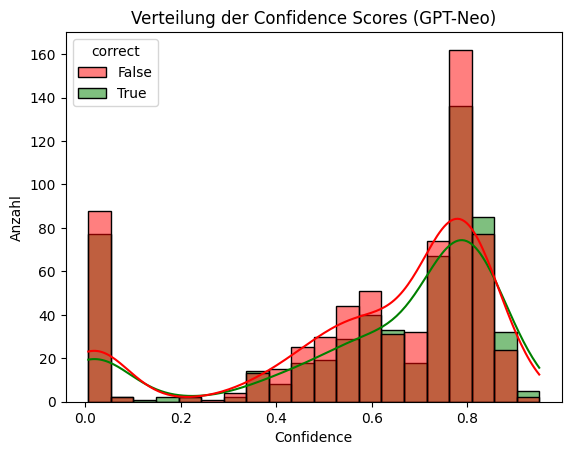

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# chain of thought

In [1]:
import torch
import os
import pandas as pd
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

# Geräte-Setup
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modell(e)
models = {
    "meta-llama/Llama-3.1-8B-Instruct": "causal"
}

# Daten laden
df_base = pd.read_csv("preprocessed_test_cleaned.csv", sep="\t").iloc[:2000]
statements = df_base["statement"].tolist()

# Chain-of-Thought Prompt
def cot_prompt(statement):
    return (
        f"Statement: {statement}\n"
        f"Task: Is this statement factually correct or fake news?\n"
        f"Think step by step based on verifiable facts, then conclude with one word: True or False.\n"
        f"Answer:"
    )

# Antwort extrahieren
def extract_cot_answer(text):
    lines = text.strip().splitlines()
    for line in reversed(lines):
        if "true" in line.lower():
            return "True"
        if "false" in line.lower():
            return "False"
    return "Uncertain"

# Hauptprozess
for model_name in models:
    print(f"🚀 Verwende Modell: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    pred_labels = []
    confidences = []

    # Token-IDs für " True" und " False"
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    for statement in tqdm(statements, desc="🤔 CoT Reasoning"):
        prompt = cot_prompt(statement)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=100,
                pad_token_id=tokenizer.eos_token_id
            )

        decoded = tokenizer.decode(output[0], skip_special_tokens=True)
        response = decoded[len(prompt):].strip()
        prediction = extract_cot_answer(response)
        pred_labels.append(prediction)

        # Confidence berechnen (Wahrscheinlichkeit auf nächstes Token)
        with torch.no_grad():
            logits = model(**inputs).logits
            next_token_logits = logits[0, -1, :]
            probs = F.softmax(next_token_logits, dim=-1)
            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()
            confidence = max(prob_true, prob_false)
            confidences.append(confidence)

    # Speichern im Format für deine Auswertung
    df_base["label_Llama-3.1-8B-Instruct"] = pred_labels
    df_base["confidence_Llama-3.1-8B-Instruct"] = confidences


🚀 Verwende Modell: meta-llama/Llama-3.1-8B-Instruct


2025-07-03 14:40:30.546700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751546430.565423   33210 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751546430.570462   33210 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 14:40:30.589088: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🤔 CoT Reasoning: 100%|██████████| 1267/1267 [1:04:10<00:00,  3.04s/it]


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
df=df_base
# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_Llama-3.1-8B-Instruct"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[318 396]
 [183 370]]

Accuracy:  0.5430149960536701
Precision: 0.6347305389221557  (bezogen auf 'True')
Recall:    0.44537815126050423  (bezogen auf 'True')
F1 Score:  0.5234567901234568  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.67      0.56       553
       False       0.63      0.45      0.52       714

    accuracy                           0.54      1267
   macro avg       0.56      0.56      0.54      1267
weighted avg       0.57      0.54      0.54      1267



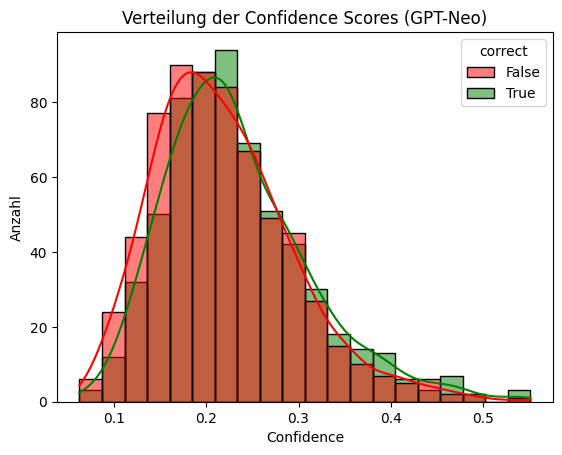

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_Llama-3.1-8B-Instruct"]

sns.histplot(data=df, x="confidence_Llama-3.1-8B-Instruct", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()